# 单摆运动数据集生成

## 单摆的运动公式

假设摆球的体积忽略不计，质量全部集中在一个点上

假设绳子的质量为零，且在运动过程中长度 $l$ 保持不变

假设忽略空气阻力和支点的摩擦力

设单摆的摆长为 $l$，摆锤的质量为 $m$，摆锤偏离平衡位置的角度为 $\theta$ (从平衡位置开始顺时针方向为正, 逆时针方向为负)，则单摆的运动公式表示为

$$\frac{d^2\theta}{dt^2} + \frac{g}{l} \sin\theta = 0$$

## 输入

摆长 $l$ (噪声)

重力加速度 $g = 9.81\,\mathrm{m/s^2}$

初始角度 $\theta_0$ (噪声)

初始角速度 $\omega_0 = 0$ 

时间 $t$

## 输出

$t$ 时刻的角度 $\theta$

# `ode_prediction_data.csv` 数据说明

文件路径：`data/raw/algorithm_prediction_data/ode_prediction_data.csv`。由 `intuition_physics_ml/ode_prediction_data.py` 生成。


| 列名 | 含义 | 单位 / 备注 |
|------|------|-------------|
| `traj_id` | 样本编号，从 0 递增 | 整数，每行唯一 |
| `case_id` | 物理 case 编号 | 同一 `case_id` 共享相同的 `l`、`theta0`，可有多个 `t` |
| `t` | 本行预测所对应的时刻 | 秒 (s)，落在「首次过平衡」与「对侧顶点」之间的开区间内 |
| `l` | 摆长（测量值，已做下界裁剪保证为正） | 米 (m) |
| `theta0` | \(t=0\) 时的摆角（测量值） | 弧度 (rad) |
| `omega0` | \(t=0\) 角速度 | 恒为 0 |
| `theta0_deg` | 与 `theta0` 相同，换算为度 | 度 (°) |
| `g` | 重力加速度常数 | m/s² |
| `theta` | 在时刻 `t` 的摆角（由 ODE 积分得到） | rad |
| `theta_deg` | 与 `theta` 相同，换算为度 | ° |


In [1]:
%matplotlib inline

# 导入依赖
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# 解决中文显示问题
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

_here = Path.cwd().resolve()
_root = next((p for p in (_here, *_here.parents) if (p / "pyproject.toml").is_file()), None)
if _root is None:
    raise RuntimeError("请在仓库根目录或 notebooks/ 下打开本 notebook")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from intuition_physics_ml.ode_prediction_data import (
    default_ode_prediction_csv_path,
    generate_and_save_ode_prediction_data,
)

csv_path = default_ode_prediction_csv_path()
_min_rows = 4000
if csv_path.is_file():
    df = pd.read_csv(csv_path)
else:
    df = None
if df is None or len(df) < _min_rows:
    generate_and_save_ode_prediction_data(n_cases=1000, n_times_per_case=10, rng_seed=42)
    df = pd.read_csv(csv_path)

print(csv_path.resolve(), df.shape)
df.head()

E:\MyGithubProject\IntuitionPhysicsProjectCode\data\raw\algorithm_prediction_data\ode_prediction_data.csv (16384, 9)


,traj_id,t,l,theta0,omega0,theta0_deg,g,theta,theta_deg
0,0,0.622049,1.281461,-0.100929,0.0,-5.782807,9.81,0.015007,0.859824
1,1,1.121784,1.281461,-0.100929,0.0,-5.782807,9.81,0.100849,5.778232
2,2,1.000183,1.281461,-0.100929,0.0,-5.782807,9.81,0.093880,5.378934
3,3,1.014314,1.281461,-0.100929,0.0,-5.782807,9.81,0.095256,5.457755
4,4,0.641289,1.281461,-0.100929,0.0,-5.782807,9.81,0.020294,1.162752


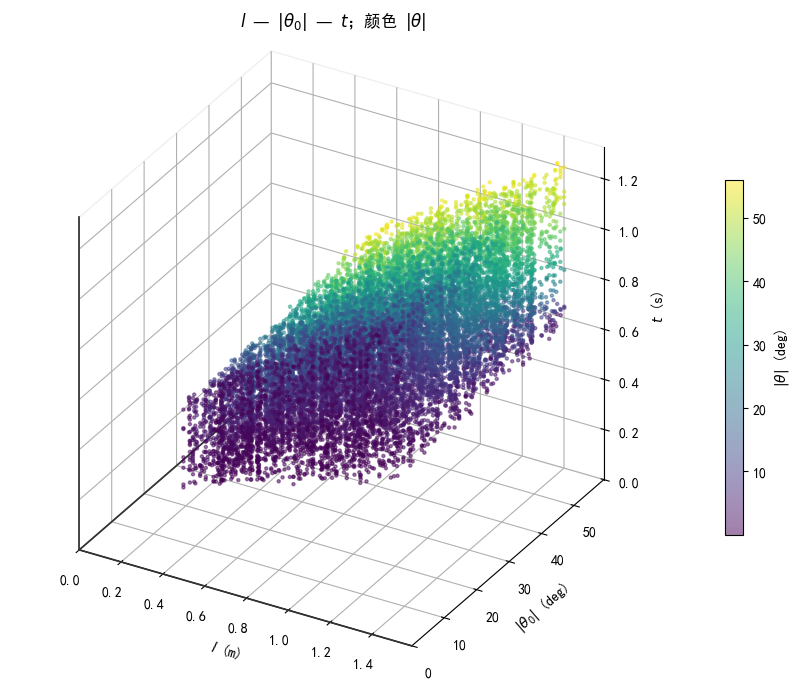

In [2]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.set_proj_type("ortho")

abs_theta0 = df["theta0_deg"].abs()
abs_theta = df["theta_deg"].abs()
sc = ax.scatter(
    df["l"],
    abs_theta0,
    df["t"],
    c=abs_theta,
    cmap="viridis",
    s=5,
    alpha=0.5,
    depthshade=True,
)

xmax = max(float(df["l"].max()) * 1.05, 1e-6)
ymax = max(float(abs_theta0.max()) * 1.05, 1e-6)
zmax = max(float(df["t"].max()) * 1.05, 1e-6)
ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)
ax.set_zlim(0, zmax)
ax.set_box_aspect((1, 1, 1))

ax.plot([0, xmax], [0, 0], [0, 0], color="0.2", lw=1.25, zorder=2)
ax.plot([0, 0], [0, ymax], [0, 0], color="0.2", lw=1.25, zorder=2)
ax.plot([0, 0], [0, 0], [0, zmax], color="0.2", lw=1.25, zorder=2)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 0.9))
    axis.pane.set_edgecolor("0.88")

ax.set_xlabel(r"$l$ (m)")
ax.set_ylabel(r"$|\theta_0|$ (deg)")
ax.set_zlabel(r"$t$ (s)")
plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.08, label=r"$|\theta|$ (deg)")
ax.set_title(r"$l$ — $|\theta_0|$ — $t$；颜色 $|\theta|$")
plt.tight_layout()
plt.show()